# Descripción y preparación de los datos — PM2.5 Pekín

**Proyecto de Aprendizaje Automático en Series Temporales y Flujos de Datos**

Este cuaderno cubre la fase de **descripción y preparación de los datos**: características temporales, calidad, granularidad, tratamiento de valores ausentes y atípicos, y codificación de variables categóricas. Es la continuación natural del cuaderno de análisis exploratorio (`02_analisis_exploratorio.ipynb`), del que se reutilizan los hallazgos de diagnóstico ya obtenidos.

## 1. Carga de datos y características temporales

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('PRSA_data_2010.1.1-2014.12.31.csv')
df['datetime'] = pd.to_datetime(df[['year','month','day','hour']])
df = df.set_index('datetime').sort_index()
df.head()

,No,year,month,day,hour,pm2.5,DEWP,TEMP,PRES,cbwd,Iws,Is,Ir
datetime,,,,,,,,,,,,,
2010-01-01 00:00:00,1,2010,1,1,0,NaN,-21,-11.0,1021.0,NW,1.79,0,0
2010-01-01 01:00:00,2,2010,1,1,1,NaN,-21,-12.0,1020.0,NW,4.92,0,0
2010-01-01 02:00:00,3,2010,1,1,2,NaN,-21,-11.0,1019.0,NW,6.71,0,0
2010-01-01 03:00:00,4,2010,1,1,3,NaN,-21,-14.0,1019.0,NW,9.84,0,0
2010-01-01 04:00:00,5,2010,1,1,4,NaN,-20,-12.0,1018.0,NW,12.97,0,0


In [2]:
# Granularidad y cobertura temporal
print("Frecuencia nominal: horaria")
print("Rango:", df.index.min(), "->", df.index.max())
print("Número de observaciones:", len(df))

# Verificación de continuidad (sin huecos de timestamp) y de duplicados
full_range = pd.date_range(df.index.min(), df.index.max(), freq='h')
print("Huecos de timestamp:", len(full_range.difference(df.index)))
print("Timestamps duplicados:", df.index.duplicated().sum())
print("Índice ordenado cronológicamente:", df.index.is_monotonic_increasing)

Frecuencia nominal: horaria
Rango: 2010-01-01 00:00:00 -> 2014-12-31 23:00:00
Número de observaciones: 43824
Huecos de timestamp: 0
Timestamps duplicados: 0
Índice ordenado cronológicamente: True


**Observación:** la serie tiene granularidad horaria constante en todo el periodo (2010-01-01 a 2014-12-31, 43.824 observaciones), sin huecos en la línea temporal, sin timestamps duplicados y correctamente ordenada. Esto confirma que la estructura temporal del dataset es sólida; los problemas de calidad, como se ve a continuación, están en los *valores* de las variables, no en el índice temporal.

**Adecuación de la granularidad al problema:** la resolución horaria es directamente adecuada para el objetivo del proyecto. El horizonte de predicción (24 horas) es un múltiplo exacto de la unidad temporal, por lo que no es necesario ningún remuestreo. Además, se descarta agregar la serie a resolución diaria: el análisis exploratorio mostró un ciclo diario muy marcado (máximos nocturnos, mínimos a media tarde) que se perdería al promediar por días, y los episodios de contaminación pueden iniciarse o disiparse en cuestión de horas. Mantener la resolución horaria preserva ambas fuentes de información, relevantes para un sistema de alerta temprana.

## 2. Calidad de los datos: valores ausentes

In [3]:
# Nulos por columna
df.isna().sum()

No          0
year        0
month       0
day         0
hour        0
pm2.5    2067
DEWP        0
TEMP        0
PRES        0
cbwd        0
Iws         0
Is          0
Ir          0
dtype: int64

**Observación:** únicamente la variable objetivo `pm2.5` presenta valores ausentes (2.067, un 4,7% de la serie); todas las variables meteorológicas exógenas están completas.

### 2.1 Tipos de datos y verificación de rangos plausibles

In [4]:
# Tipos de datos de cada columna
df.dtypes

No         int64
year       int64
month      int64
day        int64
hour       int64
pm2.5    float64
DEWP       int64
TEMP     float64
PRES     float64
cbwd         str
Iws      float64
Is         int64
Ir         int64
dtype: object

**Observación:** las variables numéricas se leen con tipos heterogéneos (`DEWP`, `Is` e `Ir` como enteros; `TEMP`, `PRES`, `Iws` y `pm2.5` como decimales). Se debe únicamente al formato de origen del fichero (el punto de rocío se registra redondeado a grados enteros y las horas de lluvia/nieve son recuentos) y no afecta al análisis: todas son numéricas y operables. La única variable no numérica es `cbwd`, que se codifica más adelante (apartado 5).

In [5]:
# Rangos observados de cada variable numérica
rangos = df[['pm2.5','DEWP','TEMP','PRES','Iws','Is','Ir']].describe().T[['min','max','mean']]
rangos

,min,max,mean
pm2.5,0.00,994.0,98.613215
DEWP,-40.00,28.0,1.817246
TEMP,-19.00,42.0,12.448521
PRES,991.00,1046.0,1016.447654
Iws,0.45,585.6,23.889140
Is,0.00,27.0,0.052734
Ir,0.00,36.0,0.194916


In [6]:
# Comprobaciones de plausibilidad física
print("pm2.5 negativo:                 ", (df['pm2.5'] < 0).sum())
print("Temperatura fuera de [-40, 45]°C:", ((df['TEMP'] < -40) | (df['TEMP'] > 45)).sum())
print("Presión fuera de [950, 1060] hPa:", ((df['PRES'] < 950) | (df['PRES'] > 1060)).sum())
print("Iws / Is / Ir negativos:        ", ((df['Iws'] < 0) | (df['Is'] < 0) | (df['Ir'] < 0)).sum())

# Coherencia entre variables: el punto de rocío no puede superar la temperatura
inconsistentes = df[df['DEWP'] > df['TEMP']]
print("Horas con DEWP > TEMP:          ", len(inconsistentes))
inconsistentes[['DEWP','TEMP']]

pm2.5 negativo:                  0
Temperatura fuera de [-40, 45]°C: 0
Presión fuera de [950, 1060] hPa: 0
Iws / Is / Ir negativos:         0
Horas con DEWP > TEMP:           1


,DEWP,TEMP
datetime,,
2010-10-08 07:00:00,13,12.0


**Observación:** no se detectan valores fuera de rangos físicamente plausibles en ninguna variable:
- `pm2.5` no toma valores negativos (mínimo 0, máximo 994 µg/m³, compatible con episodios extremos documentados en Pekín).
- La temperatura (-19 a 42 °C) y la presión (991 a 1046 hPa) son coherentes con el clima continental de Pekín.
- El punto de rocío alcanza valores muy bajos (hasta -40 °C), propios del aire invernal extremadamente seco de la región.
- `Iws`, `Is` e `Ir` son **acumulados** (velocidad de viento acumulada y horas consecutivas de nieve/lluvia), lo que explica máximos elevados como 585,6 en `Iws` sin que sean anómalos.

Solo aparece **una hora** en la que el punto de rocío supera a la temperatura (13 °C frente a 12 °C), físicamente imposible en sentido estricto. Al ser una diferencia de 1 °C y estar `DEWP` redondeado a grados enteros, se atribuye a un error de redondeo y no se modifica. Las variables exógenas no requieren, por tanto, ninguna corrección.

In [7]:
# Caracterización de los huecos de pm2.5: longitud de cada bloque de NaN consecutivos
na_mask = df['pm2.5'].isna()
s = na_mask.astype(int)
runs = (s.diff() != 0).cumsum()
run_lengths = s.groupby(runs).sum()
run_lengths = run_lengths[run_lengths > 0]

print("Número de bloques de NaN:", len(run_lengths))
print(run_lengths.describe())

for umbral in [3, 6, 12, 24]:
    cortos = run_lengths[run_lengths <= umbral]
    largos = run_lengths[run_lengths > umbral]
    print(f"Umbral {umbral:>2}h -> {len(cortos):>3} bloques cortos ({cortos.sum():>4}h) | "
          f"{len(largos):>3} bloques largos ({largos.sum():>4}h)")

Número de bloques de NaN: 214
count    214.000000
mean       9.658879
std       21.413665
min        1.000000
25%        1.000000
50%        1.000000
75%        7.000000
max      155.000000
Name: pm2.5, dtype: float64
Umbral  3h -> 143 bloques cortos ( 176h) |  71 bloques largos (1891h)
Umbral  6h -> 158 bloques cortos ( 250h) |  56 bloques largos (1817h)
Umbral 12h -> 179 bloques cortos ( 435h) |  35 bloques largos (1632h)
Umbral 24h -> 194 bloques cortos ( 726h) |  20 bloques largos (1341h)


**Observación:** los huecos no se reparten de forma homogénea. La mayoría son puntuales (mediana de 1 hora), pero una parte sustancial de las horas ausentes se concentra en bloques largos (varios días seguidos, hasta 155h). Se opta por un **umbral de 6 horas** para diferenciar el tratamiento: por debajo de ese umbral, la variable cambia con suficiente lentitud dentro de una ventana tan corta como para que un relleno simple sea razonable; por encima, imputar equivaldría a inventar una evolución de varios días que no se puede sustentar con la información disponible.

## 3. Estrategia de imputación

Se aplican dos reglas, evitando en todo momento el uso de información futura de forma sistemática (posible fuente de fuga de información):

1. **Bloque inicial** (24 horas sin ningún valor previo disponible, al ser el arranque de la serie): se rellena con el primer valor válido posterior (`bfill`). Es un caso excepcional de inicialización, no una imputación en mitad de la serie, por lo que no introduce fuga de información de cara al pronóstico.
2. **Resto de huecos**: se aplica `ffill(limit=6)` — relleno hacia adelante (usa únicamente el último valor conocido, nunca uno posterior) limitado a un máximo de 6 horas consecutivas. Esto completa los huecos cortos por completo y cubre solo las primeras 6 horas de los huecos largos, dejando el resto de estos últimos como `NaN` de forma deliberada.

In [8]:
pm25_original = df['pm2.5'].copy()

# 1) Bloque inicial sin valor previo: inicialización con bfill
first_valid = pm25_original.first_valid_index()
pm25_prep = pm25_original.copy()
pm25_prep.loc[:first_valid] = pm25_prep.loc[:first_valid].bfill()

# 2) Resto de la serie: forward-fill limitado a 6h (solo información pasada)
pm25_prep = pm25_prep.ffill(limit=6)

# Indicador de qué horas fueron imputadas
pm25_imputado = pm25_original.isna() & pm25_prep.notna()

df['pm2.5_prep'] = pm25_prep
df['pm2.5_imputado'] = pm25_imputado

print("NaN originales:               ", pm25_original.isna().sum())
print("NaN tras imputación acotada:  ", pm25_prep.isna().sum())
print("Horas imputadas (bfill inicial + ffill<=6h):", pm25_imputado.sum())
print("Horas que permanecen como NaN (huecos largos, sin imputar):", pm25_prep.isna().sum())

NaN originales:                2067
NaN tras imputación acotada:   1463
Horas imputadas (bfill inicial + ffill<=6h): 604
Horas que permanecen como NaN (huecos largos, sin imputar): 1463


**Decisión para la fase de modelado**: las 1.463 horas que permanecen como `NaN` (huecos largos) **no se rellenarán de forma artificial**. Se excluirán de los conjuntos de entrenamiento/evaluación en el momento de construir las variables predictivas (`dropna` al generar `X`/`y`), tal como se hace en el material de referencia de la asignatura. La columna `pm2.5_imputado` se conserva como variable auxiliar de trazabilidad, útil para poder filtrar u observar el efecto de la imputación si fuera necesario más adelante.

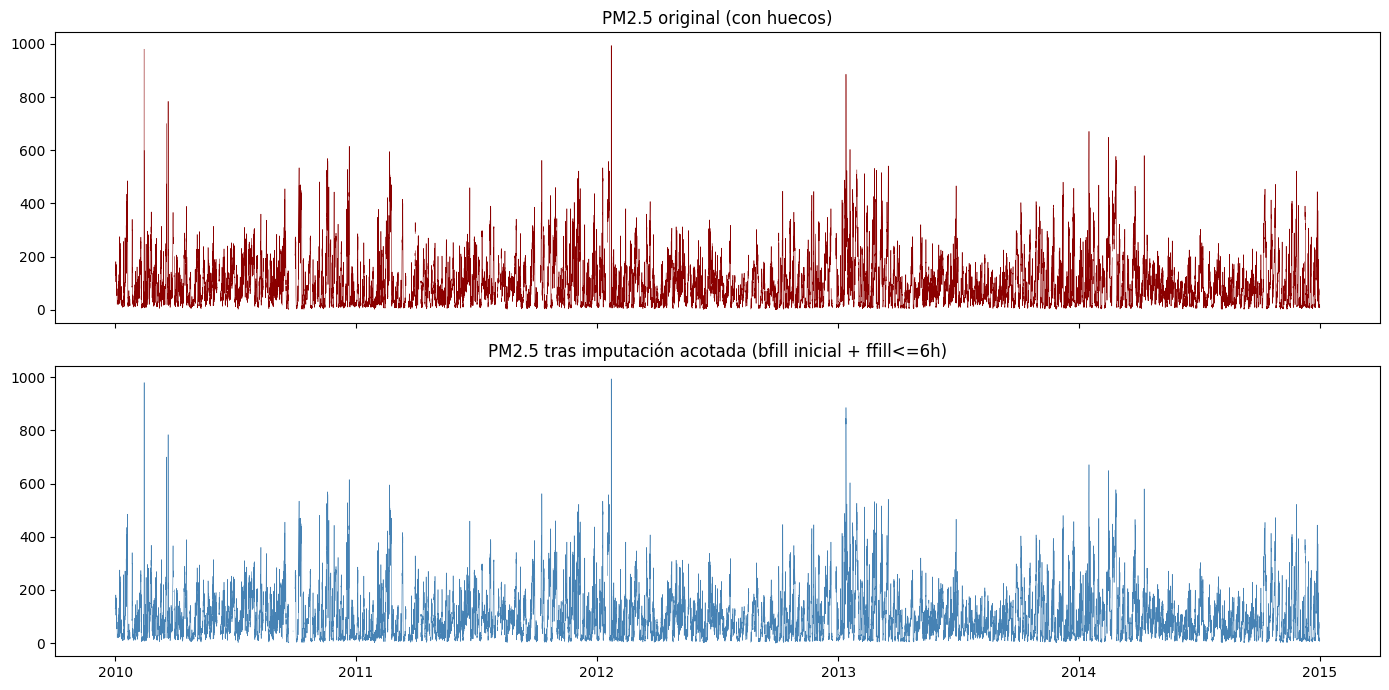

In [9]:
# Comparación visual: serie original (con huecos) vs. serie preparada
fig, axes = plt.subplots(2, 1, figsize=(14,7), sharex=True)
axes[0].plot(df.index, pm25_original, linewidth=0.4, color='darkred')
axes[0].set_title('PM2.5 original (con huecos)')
axes[1].plot(df.index, df['pm2.5_prep'], linewidth=0.4, color='steelblue')
axes[1].set_title('PM2.5 tras imputación acotada (bfill inicial + ffill<=6h)')
plt.tight_layout()
plt.show()

## 4. Detección de valores atípicos

In [10]:
# Detección de atípicos mediante criterio IQR (1.5x) sobre la serie ya imputada
valid = df['pm2.5_prep'].dropna()
q1, q3 = valid.quantile(0.25), valid.quantile(0.75)
iqr = q3 - q1
lim_inf, lim_sup = q1 - 1.5*iqr, q3 + 1.5*iqr

outliers = valid[(valid < lim_inf) | (valid > lim_sup)]
print(f"Límites IQR: [{lim_inf:.1f}, {lim_sup:.1f}]")
print(f"Valores atípicos detectados: {len(outliers)} ({len(outliers)/len(valid)*100:.1f}% de la serie)")

print("\nAtípicos por año:")
print(outliers.index.year.value_counts().sort_index())
print("\nAtípicos por mes (agregando todos los años):")
print(outliers.index.month.value_counts().sort_index())

Límites IQR: [-133.0, 299.0]
Valores atípicos detectados: 1787 (4.2% de la serie)

Atípicos por año:
datetime
2010    319
2011    341
2012    199
2013    465
2014    463
Name: count, dtype: int64

Atípicos por mes (agregando todos los años):
datetime
1     366
2     358
3     148
4      17
5       8
6      20
7      36
8      15
9      30
10    336
11    235
12    218
Name: count, dtype: int64


**Observación y decisión**: se detectan 1.787 valores por encima del límite superior del criterio IQR (el límite inferior no es aplicable, ya que `pm2.5` no toma valores negativos). Estos atípicos **no se distribuyen al azar**: se concentran claramente en los meses fríos (enero, febrero, octubre-diciembre) y en años como 2013-2014, coincidiendo con los episodios de contaminación invernal ya identificados en el análisis exploratorio (asociados al uso de calefacción). 

Esto indica que los valores atípicos, en este problema, no son errores de medición sino **episodios reales de alta contaminación** — precisamente el fenómeno que el proyecto pretende anticipar. Por tanto, **se decide no eliminarlos ni recortarlos**: hacerlo eliminaría la señal más relevante para el objetivo del proyecto (alerta temprana ante contaminación elevada). Se mantiene esta decisión documentada en la memoria como una justificación metodológica explícita.

## 5. Codificación de la variable categórica `cbwd`

In [11]:
df['cbwd'].value_counts()

cbwd
SE    15290
NW    14150
cv     9387
NE     4997
Name: count, dtype: int64

In [12]:
# Codificación one-hot: no existe un orden natural entre direcciones de viento,
# y el análisis exploratorio (apartado de exógenas) mostró un efecto no lineal por categoría
cbwd_dummies = pd.get_dummies(df['cbwd'], prefix='viento')
df = pd.concat([df, cbwd_dummies], axis=1)
df[['cbwd'] + list(cbwd_dummies.columns)].head()

,cbwd,viento_NE,viento_NW,viento_SE,viento_cv
datetime,,,,,
2010-01-01 00:00:00,NW,False,True,False,False
2010-01-01 01:00:00,NW,False,True,False,False
2010-01-01 02:00:00,NW,False,True,False,False
2010-01-01 03:00:00,NW,False,True,False,False
2010-01-01 04:00:00,NW,False,True,False,False


**Justificación**: se emplea codificación one-hot en lugar de una codificación ordinal, ya que las categorías de `cbwd` (NE, NW, SE, cv) no tienen un orden natural entre sí. El análisis exploratorio ya mostró que el efecto sobre `pm2.5` es marcadamente no lineal por categoría (NW asociado a menor contaminación, cv a mayor), por lo que una codificación ordinal arbitraria introduciría una relación de orden inexistente. Se conserva además la variable `viento_NW`, ya identificada en el análisis de correlación cruzada como indicador adelantado relevante (ver apartado 3.7 del análisis exploratorio).

## 6. Resumen del dataset preparado

In [13]:
columnas_finales = ['pm2.5_prep', 'pm2.5_imputado', 'DEWP', 'TEMP', 'PRES',
                     'Iws', 'Is', 'Ir'] + list(cbwd_dummies.columns)
df_prep = df[columnas_finales].copy()
df_prep = df_prep.rename(columns={'pm2.5_prep': 'pm2.5'})

print("Forma del dataset preparado:", df_prep.shape)
print("\nNulos restantes por columna:")
print(df_prep.isna().sum())
df_prep.describe()

Forma del dataset preparado: (43824, 12)

Nulos restantes por columna:
pm2.5             1463
pm2.5_imputado       0
DEWP                 0
TEMP                 0
PRES                 0
Iws                  0
Is                   0
Ir                   0
viento_NE            0
viento_NW            0
viento_SE            0
viento_cv            0
dtype: int64


,pm2.5,DEWP,TEMP,PRES,Iws,Is,Ir
count,42361.000000,43824.000000,43824.000000,43824.000000,43824.000000,43824.000000,43824.000000
mean,98.565284,1.817246,12.448521,1016.447654,23.889140,0.052734,0.194916
std,92.036988,14.433440,12.198613,10.268698,50.010635,0.760375,1.415867
min,0.000000,-40.000000,-19.000000,991.000000,0.450000,0.000000,0.000000
25%,29.000000,-10.000000,2.000000,1008.000000,1.790000,0.000000,0.000000
50%,72.000000,2.000000,14.000000,1016.000000,5.370000,0.000000,0.000000
75%,137.000000,15.000000,23.000000,1025.000000,21.910000,0.000000,0.000000
max,994.000000,28.000000,42.000000,1046.000000,585.600000,27.000000,36.000000


**Síntesis de la fase de preparación de datos**:

- Granularidad horaria constante, sin huecos de timestamp ni duplicados — la estructura temporal es correcta, y la resolución horaria es la adecuada para un horizonte de 24h y para preservar el ciclo diario.
- Las variables exógenas están completas y dentro de rangos físicamente plausibles; los tipos de datos heterogéneos se deben al formato de origen y no requieren corrección.
- Único problema de calidad relevante: 4,7% de valores ausentes en `pm2.5`, tratados de forma diferenciada según duración del hueco (relleno acotado a 6h respetando el orden temporal; huecos largos dejados como `NaN` para su exclusión explícita en el modelado, evitando inventar una evolución no sustentada por los datos).
- Los valores atípicos identificados corresponden a episodios reales de contaminación y se conservan sin modificar, por ser la señal de interés del proyecto.
- La variable categórica `cbwd` se codifica mediante one-hot, coherente con la ausencia de orden natural entre sus categorías y con el efecto no lineal observado en el análisis exploratorio.

El dataset resultante (`df_prep`) queda listo para la siguiente fase: definición de la estrategia de modelado y evaluación (horizonte, partición temporal, construcción de variables de retardo y ventana).

## 7. Exportación del dataset preparado

Se guarda `df_prep` en CSV para que la fase de modelado parta exactamente de estos datos.

In [14]:
df_prep.to_csv('PRSA_preparado.csv', index_label='datetime')
print('Guardado PRSA_preparado.csv:', df_prep.shape)

Guardado PRSA_preparado.csv: (43824, 12)
